# Time Series Exploratory Data Analysis (EDA)
### Olist Brazilian E-Commerce Platform

This notebook performs monthly time series analysis on the cleaned master dataset:
1. Groups transactions by **Month-Year** using `order_purchase_timestamp`.
2. Computes **Total Monthly Revenue** (`sum(payment_value)`) and **Total Orders** (`nunique(order_id)`).
3. Produces publication-ready visual figures with Matplotlib and Seaborn.

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import seaborn as sns

# 1. Load Processed Master Data
data_path = os.path.join("..", "Data", "Processed", "df_master.csv") if os.path.exists(os.path.join("..", "Data", "Processed", "df_master.csv")) else os.path.join("Data", "Processed", "df_master.csv")
df_master = pd.read_csv(data_path)

# Ensure datetime format
df_master["order_purchase_timestamp"] = pd.to_datetime(df_master["order_purchase_timestamp"])

print(f"Loaded df_master: {df_master.shape}")
print(f"Date Range: {df_master['order_purchase_timestamp'].min()} to {df_master['order_purchase_timestamp'].max()}")

Loaded df_master: (115035, 22)
Date Range: 2016-10-03 09:44:50 to 2018-08-29 15:00:37


## 2. Monthly Aggregation
Extract the period (month-year) and calculate total revenue and distinct order counts.

In [ ]:
# Create month-year period
df_master["year_month"] = df_master["order_purchase_timestamp"].dt.to_period("M")

# Aggregate revenue and orders
df_monthly = df_master.groupby("year_month").agg(
    total_revenue=("payment_value", "sum"),
    total_orders=("order_id", "nunique")
).reset_index()

# Convert period to timestamp for seamless plotting
df_monthly["timestamp"] = df_monthly["year_month"].dt.to_timestamp()

display(df_monthly.head(10))

,year_month,total_revenue,total_orders,timestamp
0,2016-10,61746.94,265,2016-10-01
1,2016-12,19.62,1,2016-12-01
2,2017-01,176491.49,750,2017-01-01
3,2017-02,325782.66,1653,2017-02-01
4,2017-03,505735.83,2546,2017-03-01
5,2017-04,456108.32,2303,2017-04-01
6,2017-05,701313.60,3546,2017-05-01
7,2017-06,585400.98,3135,2017-06-01
8,2017-07,716069.98,3872,2017-07-01
9,2017-08,842689.94,4193,2017-08-01


## 3. Ready Visualization


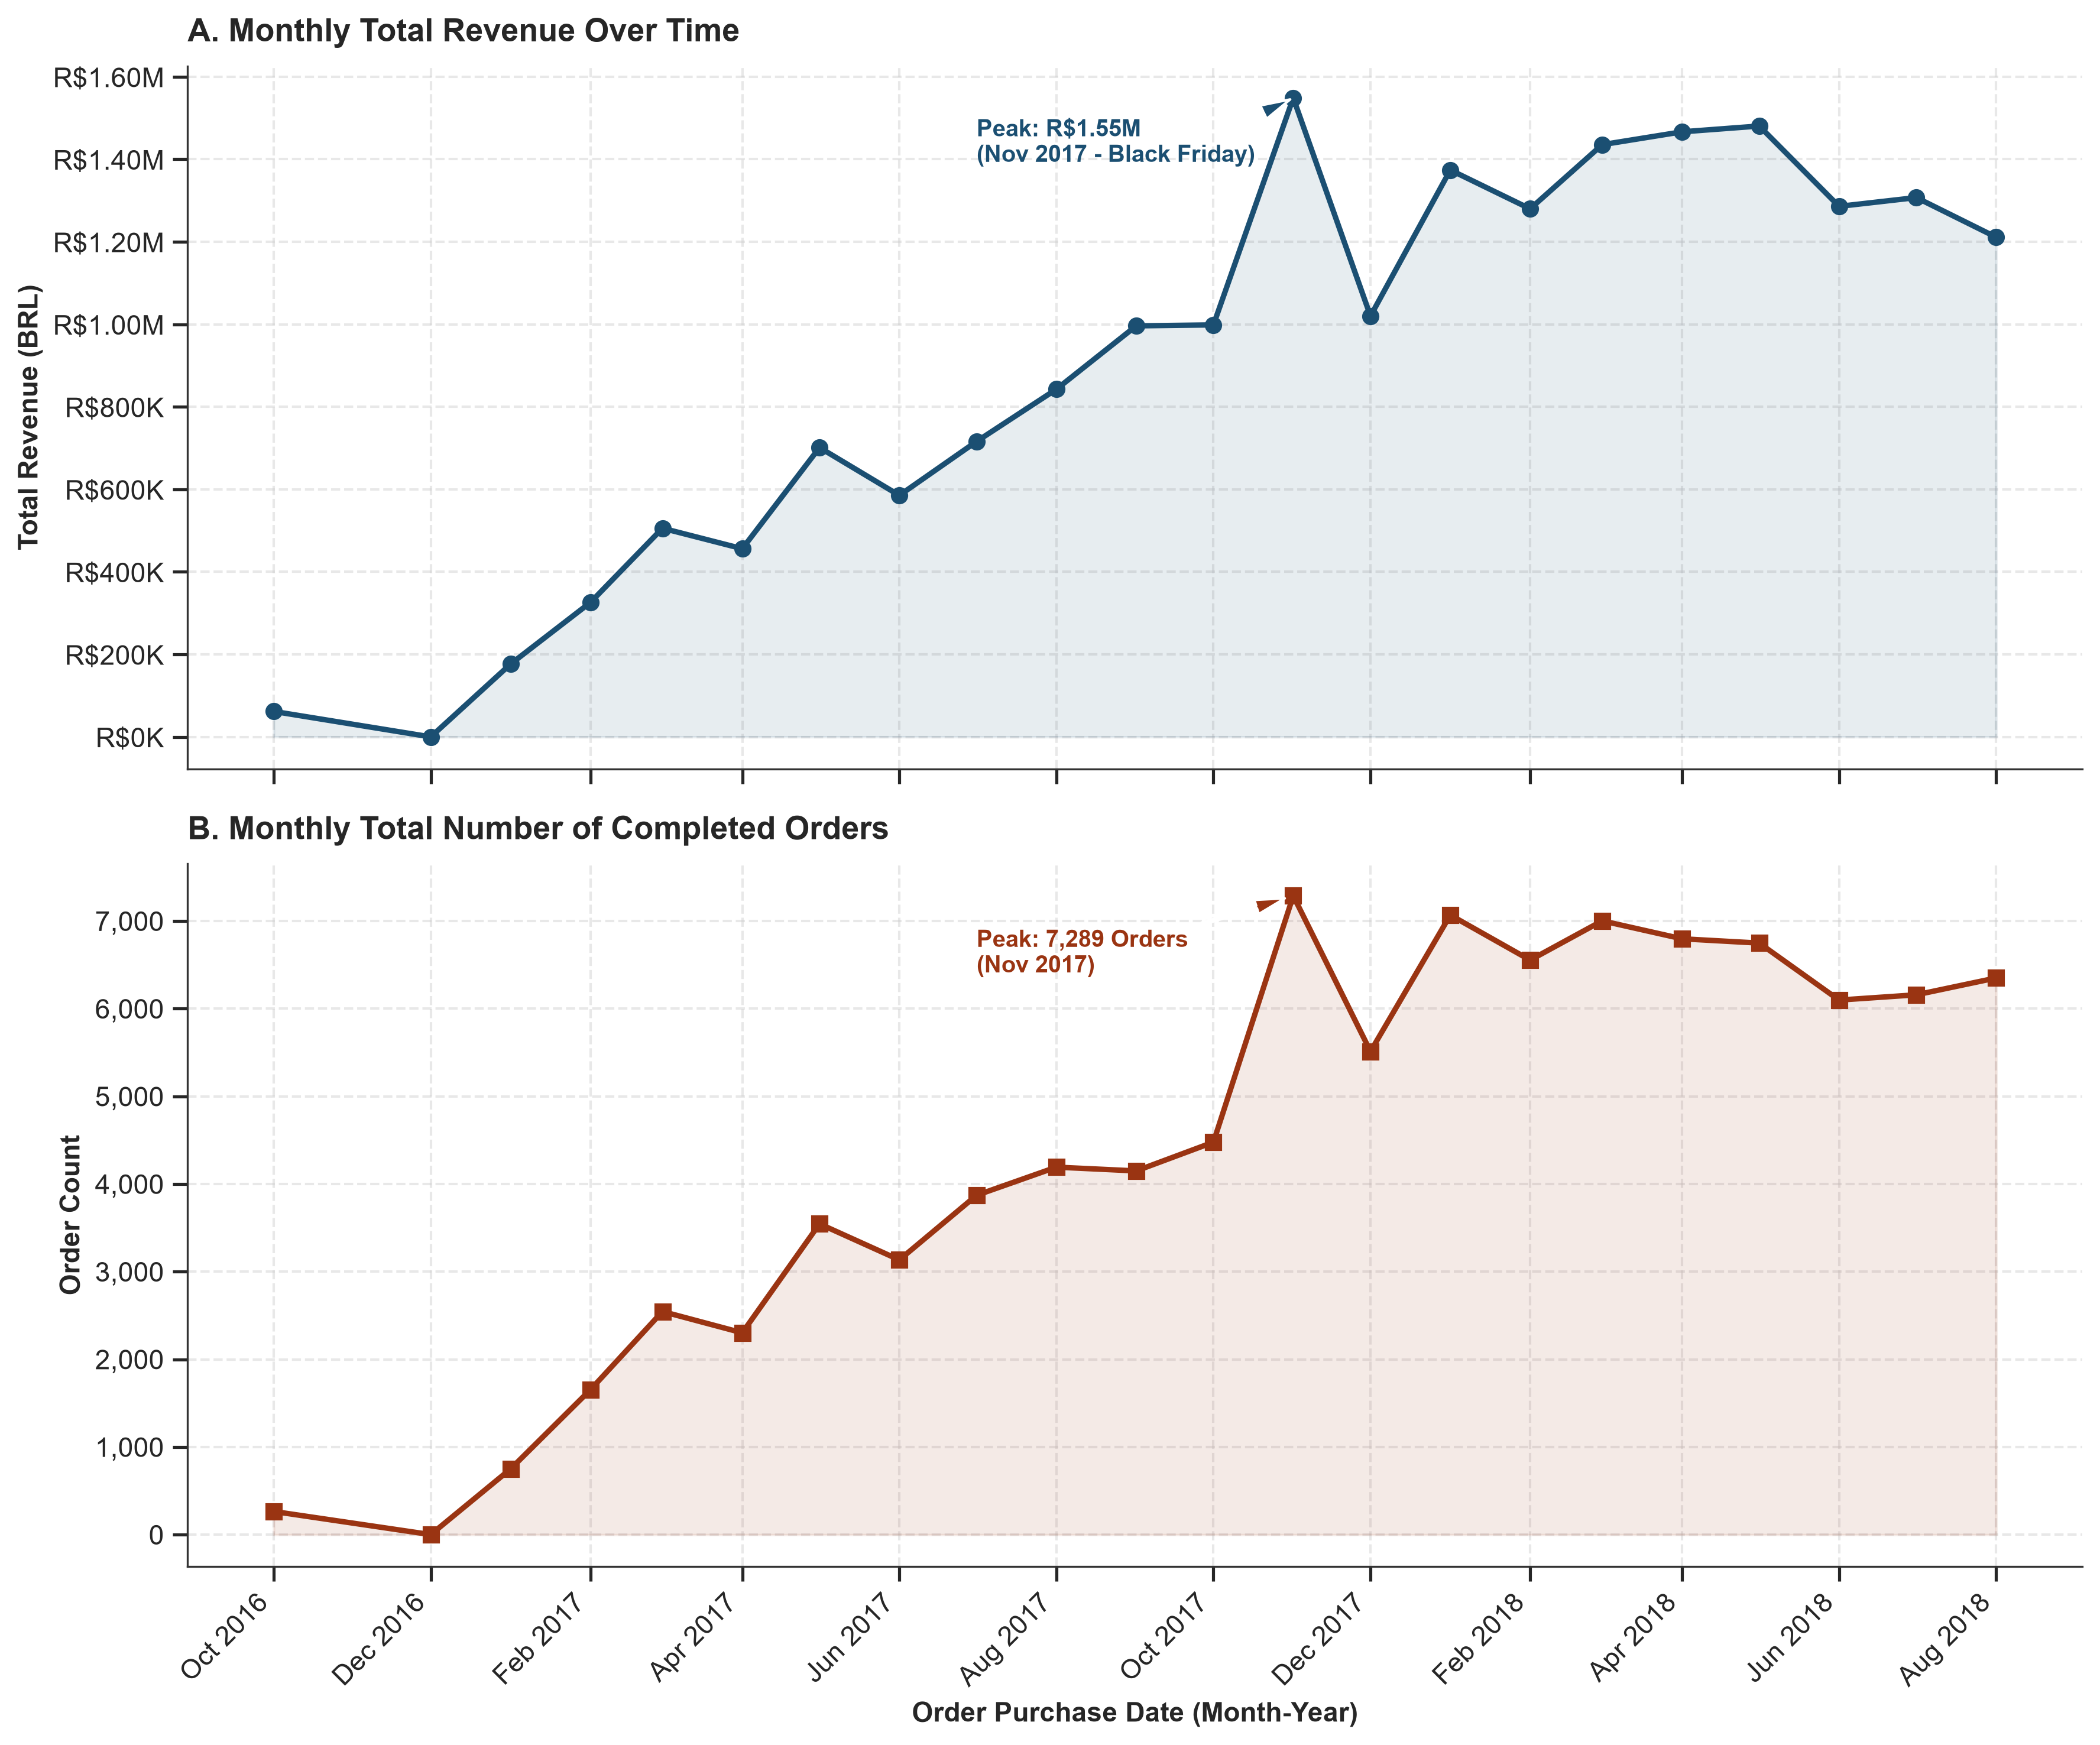

In [ ]:
# Set overall style and aesthetics
sns.set_theme(style="ticks", font="sans-serif")
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

# Palette
COLOR_REVENUE = "#1B4F72"  # Deep Navy / Sapphire
COLOR_ORDERS  = "#9A3412"  # Warm Terracotta / Copper

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True, dpi=300)

# ---------------------------------------------------------
# Panel 1: Total Monthly Revenue
# ---------------------------------------------------------
ax1.plot(
    df_monthly["timestamp"],
    df_monthly["total_revenue"],
    color=COLOR_REVENUE,
    marker="o",
    markersize=6,
    linewidth=2.2,
    label="Total Revenue (BRL)"
)
ax1.fill_between(df_monthly["timestamp"], df_monthly["total_revenue"], color=COLOR_REVENUE, alpha=0.10)
ax1.set_title("A. Monthly Total Revenue Over Time", fontsize=13, fontweight="bold", loc="left", pad=10)
ax1.set_ylabel("Total Revenue (BRL)", fontsize=11, fontweight="bold")
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"R${x/1e6:.2f}M" if x >= 1e6 else f"R${x/1e3:.0f}K"))
ax1.grid(True, linestyle="--", alpha=0.45)
sns.despine(ax=ax1, top=True, right=True)

# Highlight peak month (Black Friday 2017)
max_rev_idx = df_monthly["total_revenue"].idxmax()
max_rev_date = df_monthly.loc[max_rev_idx, "timestamp"]
max_rev_val = df_monthly.loc[max_rev_idx, "total_revenue"]
ax1.annotate(
    f"Peak: R${max_rev_val/1e6:.2f}M\n(Nov 2017 - Black Friday)",
    xy=(max_rev_date, max_rev_val),
    xytext=(max_rev_date - pd.DateOffset(months=4), max_rev_val * 0.90),
    arrowprops=dict(facecolor=COLOR_REVENUE, shrink=0.08, width=1, headwidth=6),
    fontsize=9.5,
    fontweight="bold",
    color=COLOR_REVENUE
)

# ---------------------------------------------------------
# Panel 2: Total Monthly Orders
# ---------------------------------------------------------
ax2.plot(
    df_monthly["timestamp"],
    df_monthly["total_orders"],
    color=COLOR_ORDERS,
    marker="s",
    markersize=6,
    linewidth=2.2,
    label="Total Orders"
)
ax2.fill_between(df_monthly["timestamp"], df_monthly["total_orders"], color=COLOR_ORDERS, alpha=0.10)
ax2.set_title("B. Monthly Total Number of Completed Orders", fontsize=13, fontweight="bold", loc="left", pad=10)
ax2.set_xlabel("Order Purchase Date (Month-Year)", fontsize=11, fontweight="bold")
ax2.set_ylabel("Order Count", fontsize=11, fontweight="bold")
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x):,}"))
ax2.grid(True, linestyle="--", alpha=0.45)
sns.despine(ax=ax2, top=True, right=True)

# Highlight peak month on orders
max_ord_idx = df_monthly["total_orders"].idxmax()
max_ord_date = df_monthly.loc[max_ord_idx, "timestamp"]
max_ord_val = df_monthly.loc[max_ord_idx, "total_orders"]
ax2.annotate(
    f"Peak: {max_ord_val:,} Orders\n(Nov 2017)",
    xy=(max_ord_date, max_ord_val),
    xytext=(max_ord_date - pd.DateOffset(months=4), max_ord_val * 0.88),
    arrowprops=dict(facecolor=COLOR_ORDERS, shrink=0.08, width=1, headwidth=6),
    fontsize=9.5,
    fontweight="bold",
    color=COLOR_ORDERS
)

# Date axis formatting
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

# Save publication figure
results_dir = os.path.join("..", "Results") if os.path.exists(os.path.join("..", "Results")) else "Results"
os.makedirs(results_dir, exist_ok=True)
plt.savefig(os.path.join(results_dir, "olist_monthly_timeseries_eda.png"), dpi=300, bbox_inches="tight")
plt.show()